# 03 — Theorem 22.6: reproducing the numerical worked examples

**What this shows.** C. Villani's lecture notes *Fisher Information in Kinetic Theory* (arXiv:2501.00925) state
Theorem 22.6: the Fisher information decreases along the homogeneous Boltzmann equation whenever
$\sup (r/B)|\partial_r B| \le 2\sqrt{d\,m/M}$. Here $m/M$ measures how well the angular kernel is matched by a
*subordinated heat kernel*. The notes give numerical worked examples, with bound $\ge 4.3$ in $d=3$ and $> 3.3$ in $d=2$.
This notebook recomputes them with `verification/theorem_22_6/kernels.py`. That module is an implementation written from
the mathematics, not a copy of the authors' unlicensed code. The notebook then applies the theorem to this project's
model roton kernel.

**Time:** about a minute. It uses small grids; `verification/theorem_22_6/reproduce.py` and `EXPERIMENTS.md` hold the full runs.

In [1]:
# Locate the repository root, so this notebook runs from any working directory inside it.
import sys, contextlib, io
from pathlib import Path
ROOT = Path.cwd().resolve()
while not (ROOT / "agora_swarm").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

def quiet():
    """The engine narrates each step on stdout; hide that inside loops."""
    return contextlib.redirect_stdout(io.StringIO())

import numpy as np, sympy as sp, mpmath as mp
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})
print("repository:", ROOT.name)

repository: SocrateAI-Scientific-Agora-Physique-Cinetique


d = 3: minimum bound 4.3546  (claim >= 4.3)
d = 2: minimum bound 3.3636  (claim >  3.3)


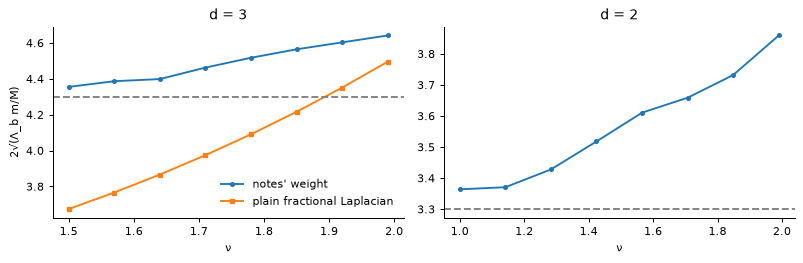

In [2]:
sys.path.insert(0, str(ROOT / "verification/theorem_22_6"))
import kernels as K
nus3 = np.linspace(1.5, 1.99, 8)       # d = 3: gamma in (-3, -2]
nus2 = np.linspace(1.0, 1.99, 8)       # d = 2
b3 = [K.compare(nu, 3, K.weight_tuned_d3(nu))["bound"] for nu in nus3]
b2 = [K.compare(nu, 2, K.weight_tuned_d2(nu))["bound"] for nu in nus2]
f3 = [K.compare(nu, 3, K.weight_fractional_laplacian(nu))["bound"] for nu in nus3]
print(f"d = 3: minimum bound {min(b3):.4f}  (claim >= 4.3)")
print(f"d = 2: minimum bound {min(b2):.4f}  (claim >  3.3)")
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(nus3, b3, "o-", ms=3, label="notes' weight"); ax[0].plot(nus3, f3, "s-", ms=3, label="plain fractional Laplacian")
ax[0].axhline(4.3, ls="--", color="grey"); ax[0].set(xlabel="ν", ylabel="2√(Λ_b m/M)", title="d = 3"); ax[0].legend(frameon=False)
ax[1].plot(nus2, b2, "o-", ms=3); ax[1].axhline(3.3, ls="--", color="grey"); ax[1].set(xlabel="ν", title="d = 2")
plt.tight_layout(); plt.show()

The hand-tuned weights matter: with the plain fractional Laplacian the $d=3$ bound falls below 4.3 over most of the range.

## An exact anchor

In $d=2$ at $\nu=1$ (2D Coulomb), the symmetrised Rutherford kernel *equals* the $(-\Delta)^{1/2}$ kernel on the circle,
$1/\sin^2\theta$. The ratio must then be exactly 1, and the bound exactly $2\cdot 2^{3/4}$.

In [3]:
r = K.compare(1.0, 2, K.weight_fractional_laplacian(1.0))
print(f"min/max ratio = {r['ratio']:.12f}   bound = {r['bound']:.10f}   2*2^(3/4) = {2 * 2**0.75:.10f}")

min/max ratio = 1.000000000000   bound = 3.3635856610   2*2^(3/4) = 3.3635856610


## Applying the theorem to the model roton kernel

The project's analytic kernel $\beta(\cos\theta) = \tfrac12(1+\cos^2\theta)e^{-(1-\cos\theta)/10}$ has no measured input.
A linear program finds the heat-kernel mixture that best matches it. The theorem then certifies Fisher-information
decay for $B = |v-v_*|^\gamma\beta$ whenever $|\gamma| \le \bar\gamma = 2\sqrt{3\,m/M}$.

In [4]:
import math
import roton_application as R
th = np.linspace(0, math.pi / 2, 401); ts = np.logspace(-2.5, 1, 61)
b = R.beta_sym(th)
scale = np.array([(R.heat_kernel_sym(t, th) / b).max() for t in ts])
w, _ = R.best_mixture(th, ts)
m_over_M = R.ratio_on(np.linspace(0, math.pi / 2, 5001), ts, w, scale)   # checked on a finer grid
print(f"m/M = {m_over_M:.5f}   gamma_bar = 2 sqrt(3 m/M) = {2 * math.sqrt(3 * m_over_M):.4f}   (ceiling 2 sqrt 3 = {2*math.sqrt(3):.4f})")

m/M = 0.99624   gamma_bar = 2 sqrt(3 m/M) = 3.4576   (ceiling 2 sqrt 3 = 3.4641)


The full run (2001-point fit grid, 50001-point check) gives $m/M = 0.99654$ and $\bar\gamma = 3.458$. This is a
property of the model kernel, not of real rotons. It replaces the project's retracted `gamma_bound` (RETRACTIONS.md R8),
and the two numbers must not be compared.